In [21]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from utils import describe_data, plot_df_chart

In [22]:
# Import libraries
import numpy as np
import yfinance as yf
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [23]:
TICKER = "ES=F"
df = yf.download(TICKER, period="max", interval="1D")

df.drop(columns=["Volume"], inplace=True)
df.columns = df.columns.droplevel("Ticker")
df.dropna(inplace=True)

df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open
Date,,,,
2026-05-18,7425.75,7454.25,7373.50,7410.00
2026-05-19,7378.00,7440.75,7354.25,7423.50
2026-05-20,7451.75,7458.00,7356.00,7377.00
2026-05-21,7466.00,7486.75,7407.50,7432.75
2026-05-22,7491.00,7524.00,7466.75,7467.00


## Daily return

In [24]:
df["Daily_return"] = 100 * (df["Close"] - df["Open"]) / df["Open"]

df.tail()

Price,Close,High,Low,Open,Daily_return
Date,,,,,
2026-05-18,7425.75,7454.25,7373.50,7410.00,0.212551
2026-05-19,7378.00,7440.75,7354.25,7423.50,-0.612918
2026-05-20,7451.75,7458.00,7356.00,7377.00,1.013285
2026-05-21,7466.00,7486.75,7407.50,7432.75,0.447345
2026-05-22,7491.00,7524.00,7466.75,7467.00,0.321414


In [25]:
plot_df_chart(
    df["Daily_return"],
    chart_type="bar",
    chart_title="Daily returns",
    yaxis_title="Daily Return (%)",
    width=1000,
    height=600,
)   

## Stats

In [26]:
df_stats, stats = describe_data(df["Daily_return"])

df_stats

,Value
Metric,
nobs,6484
Min %,-10.034861
Max %,12.223551
Mean %,0.041929
Median %,0.074622
Mode %,0.0
Variance,1.400638
Skewness,0.079282
Kurtosis,11.869069


In [27]:
X = 0.4

conditions = [
    df["Daily_return"] < -X,
    df["Daily_return"] > X
]

choices = ["bear", "bull"]

df["flag"] = np.select(conditions, choices, default="sideways")

df

Price,Close,High,Low,Open,Daily_return,flag
Date,,,,,,
2000-09-18,1467.50,1489.75,1462.25,1485.25,-1.195085,bear
2000-09-19,1478.50,1482.75,1466.75,1467.00,0.783913,bull
2000-09-20,1469.50,1480.50,1450.25,1478.75,-0.625528,bear
2000-09-21,1469.50,1474.00,1455.50,1470.25,-0.051012,sideways
2000-09-22,1468.50,1471.00,1436.75,1454.75,0.945180,bull
...,...,...,...,...,...,...
2026-05-18,7425.75,7454.25,7373.50,7410.00,0.212551,sideways
2026-05-19,7378.00,7440.75,7354.25,7423.50,-0.612918,bear
2026-05-20,7451.75,7458.00,7356.00,7377.00,1.013285,bull


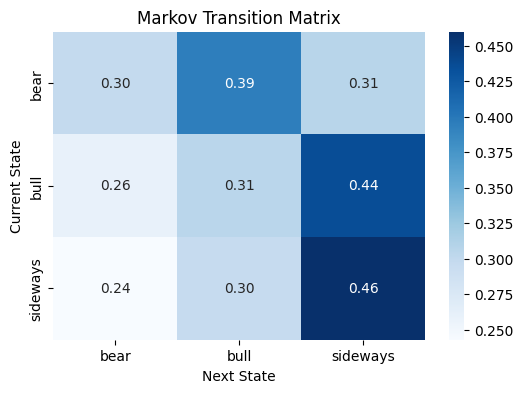

In [28]:
markov_matrix = pd.crosstab(
    df['flag'],
    df['flag'].shift(-1),
    normalize='index'
)

plt.figure(figsize=(6, 4))

sns.heatmap(
    markov_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Markov Transition Matrix")
plt.xlabel("Next State")
plt.ylabel("Current State")

plt.show()